### PyTorch Bootcamp Class #28 | How to Use Time Series Data for Sales Prediction in ERP with LSTM

https://www.youtube.com/watch?v=m2CLbHZHLB4


In [13]:
# base de vendas geradas pelo chat gpt


In [14]:
# load the dataset
import pandas as pd
arquivo = "sales_yt.csv"
df = pd.read_csv(arquivo)
df =df[['date','sales']]
df.tail()

#df=df.rename(columns={'data':'date'})
#
#df.to_csv('sales_yt.csv')

,date,sales
611,2025-09-03,1250.07
612,2025-09-04,1310.91
613,2025-09-05,1214.62
614,2025-09-06,1616.24
615,2025-09-07,1491.58


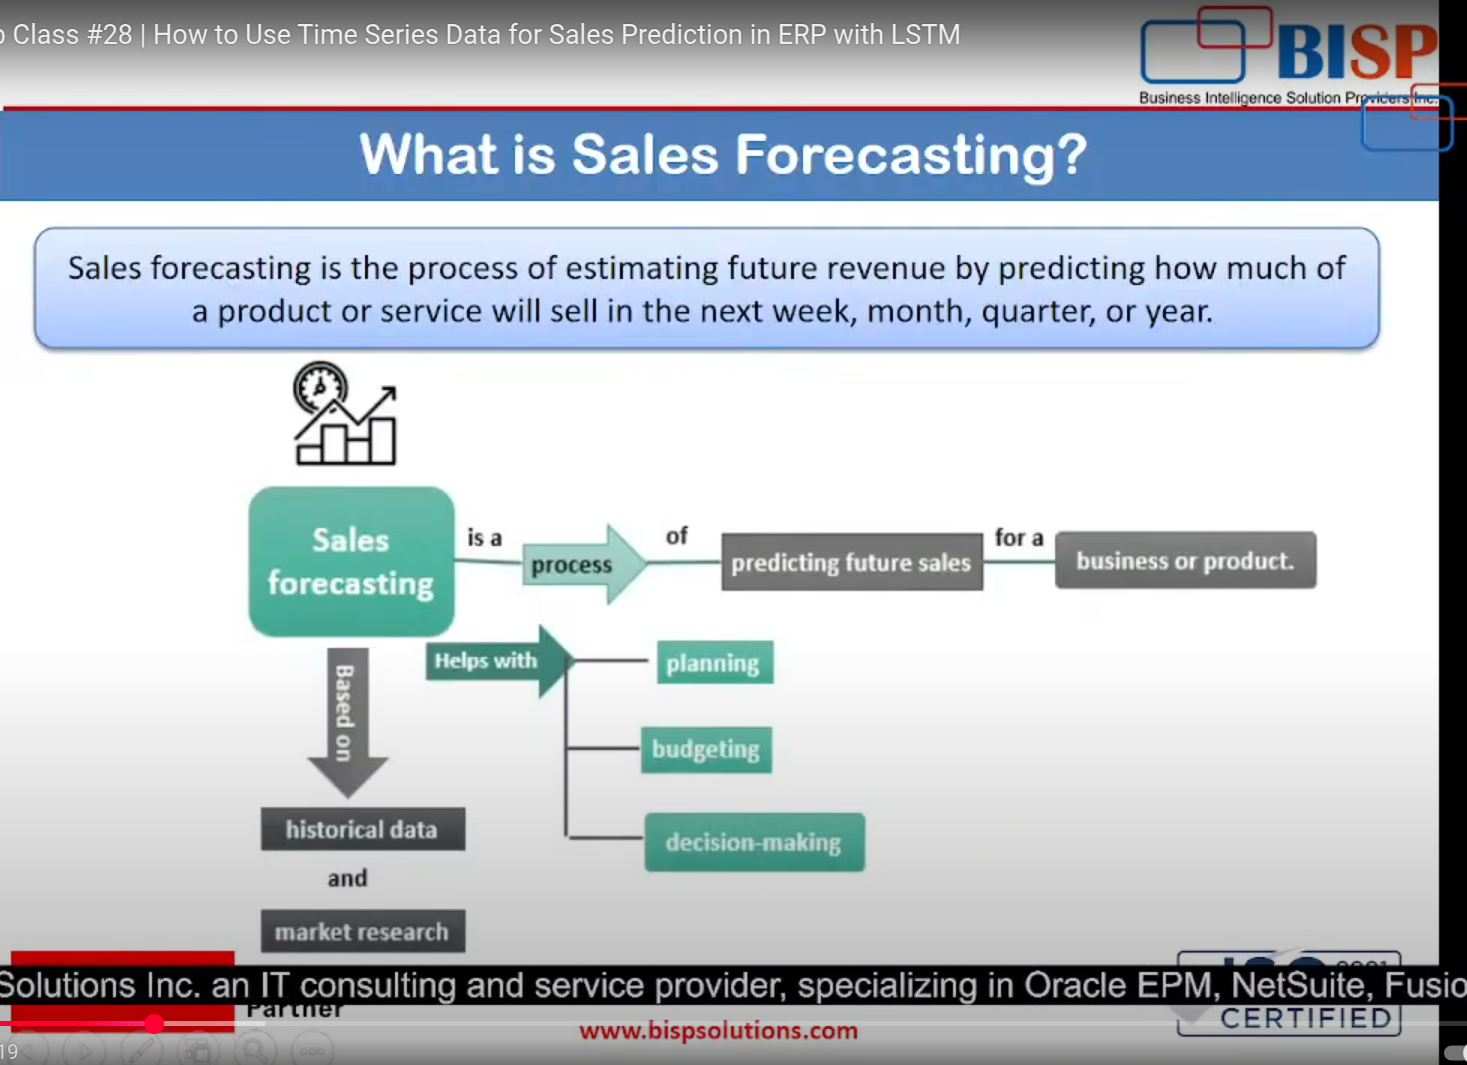

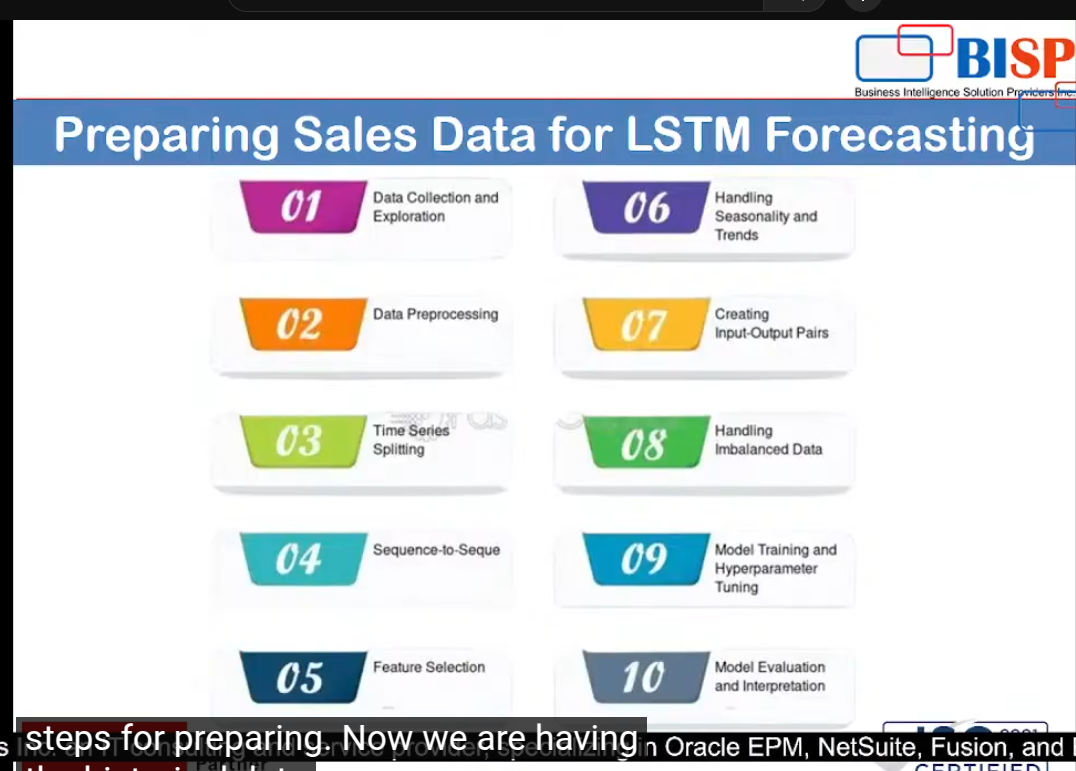

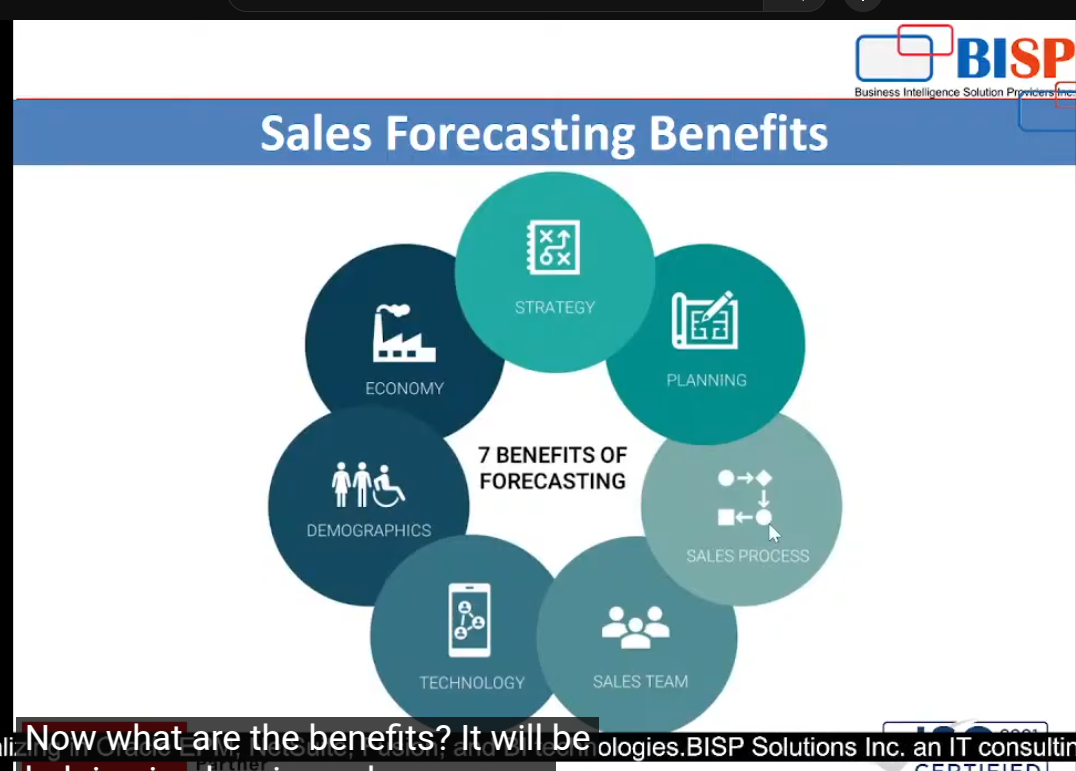

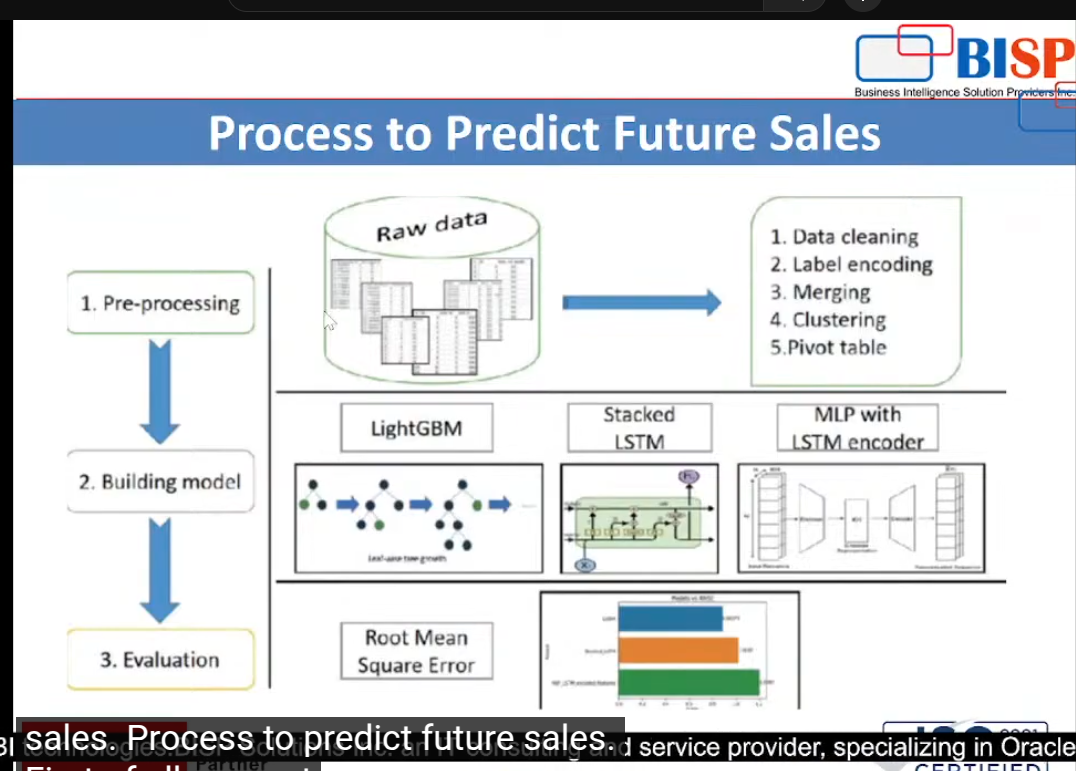

https://towardsdatascience.com/lstm-networks-a-detailed-explanation-8fae6aefc7f9/

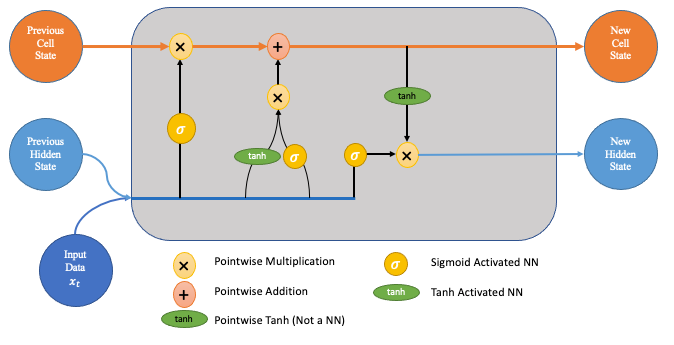

ambiente YouTube do anaconda

conda env list

conda activate YouTube

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


In [16]:
df.head()

,date,sales
0,2024-01-01,1017.93
1,2024-01-02,1042.02
2,2024-01-03,1106.29
3,2024-01-04,1143.02
4,2024-01-05,1037.18


In [17]:
# 2. Aggregate and scale

df_monthly = df.groupby('date')['sales'].sum().reset_index()

scaler= MinMaxScaler()
df_monthly['sales_scaled']= scaler.fit_transform(df_monthly[['sales']])

In [19]:
df_monthly.tail()

,date,sales,sales_scaled
611,2025-09-03,1250.07,0.526527
612,2025-09-04,1310.91,0.605195
613,2025-09-05,1214.62,0.480688
614,2025-09-06,1616.24,1.000000
615,2025-09-07,1491.58,0.838809


sequence_to_seque

https://sh-tsang.medium.com/review-seq2seq-sequence-to-sequence-learning-with-neural-networks-bcb84071a670


Seq2Seq: Sequence to Sequence Learning with Neural Networks



In [20]:
# 3. Create sequences for LSTM

SEQ_LEN = 12 # lookback window

def create_sequences(data, seq_len):
    xs, ys = [],[]
    for i in range(len(data) - seq_len):
        x = data[i:i + seq_len]
        y = data[i+seq_len]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [21]:
X, y = create_sequences(df_monthly['sales_scaled'].values, SEQ_LEN)

In [22]:
X

array([[0.22635996, 0.25750934, 0.34061316, ..., 0.34103986, 0.24022137,
        0.27495248],
       [0.25750934, 0.34061316, 0.3881066 , ..., 0.24022137, 0.27495248,
        0.58975652],
       [0.34061316, 0.3881066 , 0.25125102, ..., 0.27495248, 0.58975652,
        0.39874834],
       ...,
       [0.65756365, 0.55246518, 0.57817086, ..., 0.6052213 , 0.52652676,
        0.60519544],
       [0.55246518, 0.57817086, 0.54406041, ..., 0.52652676, 0.60519544,
        0.48068842],
       [0.57817086, 0.54406041, 0.69029055, ..., 0.60519544, 0.48068842,
        1.        ]])

In [24]:
y[:20]

array([0.58975652, 0.39874834, 0.15261776, 0.2268901 , 0.27384046,
       0.3841111 , 0.21085638, 0.47057683, 0.72846115, 0.31886419,
       0.35513402, 0.20817978, 0.25387589, 0.34056144, 0.50158398,
       0.54501726, 0.28373224, 0.31821767, 0.30571395, 0.56608092])

In [26]:
# 4. Train/test split

split = int(0.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
    
    

In [27]:
y_train.shape, X_train.shape

((483,), (483, 12))

In [31]:
# ===========================================
# 5. Dataset e DataLoader (PyTorch)
# ===========================================

# Importa a classe base para criar um dataset customizado
from torch.utils.data import Dataset, DataLoader

# Define uma classe que herda de Dataset
# Ela é responsável por fornecer os dados (X, y) de forma organizada
class SalesDataset(Dataset):
     def __init__(self, X, y):
        # Converte o conjunto de previsores (X) em tensores float32 do PyTorch
        # unsqueeze(-1) adiciona uma dimensão extra no final (necessário para RNNs/LSTMs, por exemplo)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        
        # Converte o vetor alvo (y) também em tensores float32
        self.y = torch.tensor(y, dtype=torch.float32)
        
     # Retorna o tamanho total do dataset
     def __len__(self):
         return len(self.X)
     
     # Retorna um par (X, y) correspondente ao índice informado
     def __getitem__(self, idx):
         return self.X[idx], self.y[idx]
     

# Cria o DataLoader para o conjunto de treino
# - batch_size=16 → processa 16 amostras por vez
# - shuffle=True → embaralha os dados a cada época (evita padrões fixos)
train_loader = DataLoader(SalesDataset(X_train, y_train), batch_size=16, shuffle=True)

# Cria o DataLoader para o conjunto de teste
# - batch_size=1 → avalia uma amostra por vez
# - shuffle=True → também embaralha as amostras (opcional)
test_loader = DataLoader(SalesDataset(X_test, y_test), batch_size=1, shuffle=True)


Dataset → Define como acessar e transformar seus dados.

DataLoader → Cria “lotes” (batches) de dados automaticamente e cuida do embaralhamento e da iteração durante o treino/teste.


O SalesDataset diz como pegar um dado individual,

e o DataLoader cuida de como pegar vários dados em sequência durante o treinamento.

In [32]:
train_loader

In [33]:
# ===========================================
# 6. Definição do Modelo LSTM
# ===========================================

# Importa o otimizador do PyTorch
import torch.optim

# Define uma classe para o modelo LSTM, herdando de nn.Module
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        # Inicializa a classe mãe (obrigatório em módulos PyTorch)
        super().__init__()

        # Camada LSTM (Long Short-Term Memory)
        # - input_size: número de variáveis de entrada por passo de tempo
        # - hidden_size: número de neurônios em cada célula LSTM (dimensão do estado oculto)
        # - num_layers: quantas camadas empilhadas de LSTM
        # - batch_first=True → o formato dos dados será (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Camada totalmente conectada (Linear)
        # - Pega a saída da LSTM (do último estado oculto) e a transforma em 1 valor de saída (previsão)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Passa os dados pela LSTM
        # out: saídas de todos os passos de tempo
        # _ : contém os estados oculto e de célula, que não estamos usando aqui
        out, _ = self.lstm(x)

        # Pegamos apenas a saída do último passo de tempo (out[:, -1, :])
        # pois queremos prever o próximo valor após toda a sequência
        out = self.fc(out[:, -1, :])

        # Reduz a dimensão (deixa um vetor simples em vez de matriz)
        return out.squeeze()

# ===========================================
# Instanciando o modelo
# ===========================================
model = LSTMModel()

# Define a função de perda (criterion)
# - MSELoss = Mean Squared Error (erro quadrático médio)
#   → mede o quão distante a previsão está do valor real
criterion = nn.MSELoss()

# Define o otimizador (Adam)
# - Atualiza os pesos da rede para reduzir o erro
# - lr = learning rate = 0.001 define o tamanho dos passos de ajuste dos pesos
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [34]:
# ===========================================
# 7. Loop de Treinamento (Train Loop)
# ===========================================

# Número de épocas de treinamento (quantas vezes o modelo verá todo o conjunto de treino)
EPOCHS = 30

# Lista para armazenar o erro (loss) médio de cada época
train_losses = []

# Loop principal: repete o treinamento por várias épocas
for epoch in range(EPOCHS):

    # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc.)
    model.train()

    # Acumulador para somar as perdas (loss) dessa época
    total_loss = 0

    # Loop interno: percorre os lotes (batches) de dados
    for batch_X, batch_y in train_loader:
        
        # Zera os gradientes acumulados da época anterior
        optimizer.zero_grad()

        # Faz a previsão (forward pass)
        output = model(batch_X)

        # Calcula o erro entre previsão (output) e valor real (batch_y)
        loss = criterion(output, batch_y)

        # Calcula os gradientes (backpropagation)
        loss.backward()

        # Atualiza os pesos da rede com base nos gradientes
        optimizer.step()

        # Soma o valor do erro dessa iteração (para calcular a média depois)
        total_loss += loss.item()

    # Calcula a perda média (erro médio) da época
    avg_loss = total_loss / len(train_loader)

    # Guarda a perda média na lista
    train_losses.append(avg_loss)

    # Mostra o progresso do treinamento
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}')


Epoch 1/30 - Loss: 0.0631
Epoch 2/30 - Loss: 0.0286
Epoch 3/30 - Loss: 0.0279
Epoch 4/30 - Loss: 0.0280
Epoch 5/30 - Loss: 0.0287
Epoch 6/30 - Loss: 0.0260
Epoch 7/30 - Loss: 0.0276
Epoch 8/30 - Loss: 0.0248
Epoch 9/30 - Loss: 0.0249
Epoch 10/30 - Loss: 0.0244
Epoch 11/30 - Loss: 0.0229
Epoch 12/30 - Loss: 0.0236
Epoch 13/30 - Loss: 0.0226
Epoch 14/30 - Loss: 0.0242
Epoch 15/30 - Loss: 0.0231
Epoch 16/30 - Loss: 0.0229
Epoch 17/30 - Loss: 0.0221
Epoch 18/30 - Loss: 0.0236
Epoch 19/30 - Loss: 0.0227
Epoch 20/30 - Loss: 0.0220
Epoch 21/30 - Loss: 0.0215
Epoch 22/30 - Loss: 0.0188
Epoch 23/30 - Loss: 0.0174
Epoch 24/30 - Loss: 0.0186
Epoch 25/30 - Loss: 0.0175
Epoch 26/30 - Loss: 0.0160
Epoch 27/30 - Loss: 0.0165
Epoch 28/30 - Loss: 0.0162
Epoch 29/30 - Loss: 0.0158
Epoch 30/30 - Loss: 0.0156



model.train()	Coloca o modelo em modo de treinamento.
    
optimizer.zero_grad()	Zera os gradientes acumulados.

output = model(batch_X)	Passa os dados pela rede para gerar previsões.
    
loss = criterion(output, batch_y)	Calcula o erro entre previsão e real.
    
loss.backward()	Calcula os gradientes (retropropagação).

optimizer.step()	Atualiza os pesos da rede com base nos gradientes.

avg_loss	Mede o erro médio de cada época (para monitorar aprendizado).
   

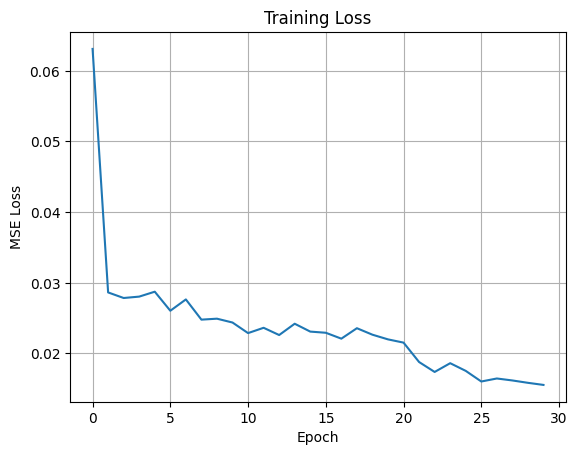

In [35]:

# 8. Plot trainig Loss
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid()
plt.show()

Plota os valores da função de perda (Loss) que você salvou em train_losses;

No eixo X, temos as épocas (quantas vezes o modelo viu todo o conjunto de dados);

No eixo Y, temos o erro médio quadrático (MSE) — quanto menor, melhor.

In [36]:
loss_duvida = """

Loss
│\
│ \
│  \
│   \______
│          \
│           \____
└──────────────────────
   0    10    20   30   → Epoch
"""

<>:1: SyntaxWarning: invalid escape sequence '\_'
<>:1: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_14719/1708799161.py:1: SyntaxWarning: invalid escape sequence '\_'
  loss_duvida = """



   
🔹 Início (Épocas 1–5):
O modelo ainda está aprendendo, então o erro (loss) cai rapidamente.

🔹 Meio (Épocas 6–15):
A curva continua caindo, mas mais devagar.
O modelo ainda melhora, porém com ganhos menores.

🔹 Final (Épocas 16–30):
A curva se estabiliza — o erro para de diminuir significativamente.
Esse é o ponto onde o modelo já aprendeu o máximo possível com os dados.

🎯 Número ideal de épocas

O número ideal de épocas é aquele onde o gráfico se estabiliza (ou seja, o loss para de cair).

Treinar além desse ponto normalmente não traz ganhos reais — pode até causar overfitting (modelo decora o treino e generaliza pior).

💡 Dica prática

Você pode automatizar a escolha do número de épocas ideal usando early stopping, ou seja:

Parar o treinamento automaticamente quando o loss não melhora mais após “N” épocas seguidas.

Situação do gráfico |Significado	| Ação ideal

Curva descendo rápido|	Modelo aprendendo|	Continue treinando

Curva começando a achatar|	Aprendizado quase completo|	Observe mais algumas épocas

Curva estabilizada (reta)|	Modelo já aprendeu o máximo|	Pare o treinamento

Curva subindo|	Overfitting|	Treinou demais, reduza épocas

In [37]:
# ======================================================
# 9. Evaluate — Avaliar o modelo no conjunto de teste
# ======================================================

# Coloca o modelo em modo de avaliação
# (desativa dropout, batch normalization etc., caso existam)
model.eval()

# Cria listas vazias para armazenar previsões e valores reais
predictions, actuals = [], []

# Desativa o cálculo de gradientes, pois não estamos treinando
# (isso torna a execução mais rápida e economiza memória)
with torch.no_grad():
    # Percorre cada lote (batch) do conjunto de teste
    for batch_X, batch_y in test_loader:
        # O modelo faz a previsão para esse lote
        pred = model(batch_X)
        # Converte o tensor de previsão em número comum e guarda
        predictions.append(pred.item())
        # Guarda também o valor real correspondente
        actuals.append(batch_y.item())


In [38]:
# ======================================================
# Inverse Scale — Volta os dados à escala original
# ======================================================

# As previsões e os valores reais estavam normalizados (entre 0 e 1)
# O scaler "desnormaliza" para os valores reais (ex: vendas em R$)
predictions_unscaled = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)
).flatten()

actuals_unscaled = scaler.inverse_transform(
    np.array(actuals).reshape(-1, 1)
).flatten()


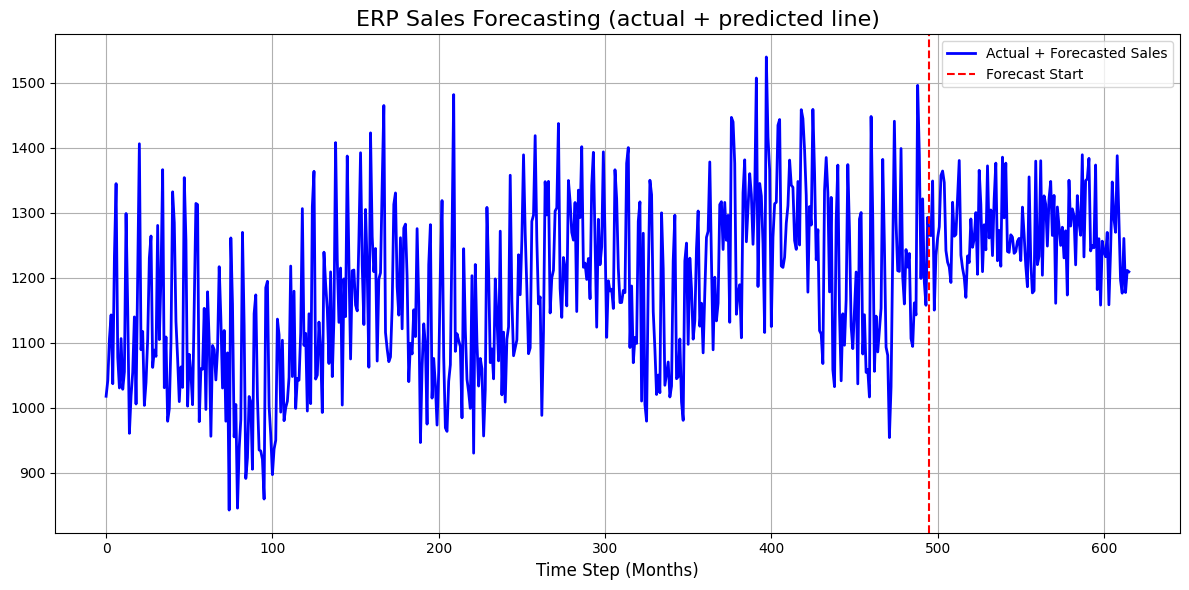

In [41]:

import matplotlib.pyplot as plt
import numpy as np

# Build full timeline with both actual + predicted
full_series = np.concatenate([scaler.inverse_transform(df_monthly['sales_scaled'].values.reshape(-1,1)).flatten()[:len(df_monthly)-len(actuals_unscaled)], predictions_unscaled])

# Plot single line for actual + predicted(continuous)
plt.figure(figsize=(12,6))
plt.plot(full_series, label = 'Actual + Forecasted Sales', color ='blue', linewidth=2)

# optional:mark split point
plt.axvline(x=len(full_series) - len(predictions_unscaled), color='red', linestyle='--', label='Forecast Start')

plt.title('ERP Sales Forecasting (actual + predicted line)', fontsize=16)
plt.xlabel('Time Step (Months)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
# ==========================================================
# Forecast future sales — Fazer previsões futuras (30 dias)
# ==========================================================

# Coloca o modelo em modo de avaliação (sem gradiente, sem dropout)
model.eval()

# Lista para armazenar as previsões (em escala normalizada)
forecast_scaled = []

# ======================================
# Começa a previsão a partir da última janela conhecida
# ======================================

# 'X[-1]' = última sequência usada no treino
# 'torch.tensor()' converte o array numpy para tensor PyTorch
# 'unsqueeze(0)' adiciona dimensão do batch (1 sequência)
# 'unsqueeze(-1)' adiciona dimensão de feature (1 variável)
#  Final: shape = [1, seq_len, 1]
last_seq = torch.tensor(X[-1], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

# ======================================
# Gera previsões em sequência (modo autorregressivo)
# ======================================
with torch.no_grad():  # Desativa cálculo de gradiente (mais rápido)
    for _ in range(30):  # Faz 30 previsões (30 dias)
        # Faz a previsão do próximo passo
        pred = model(last_seq)

        # Guarda o valor previsto (ainda na escala normalizada)
        forecast_scaled.append(pred)

        # Atualiza a janela deslizante (sliding window):
        # remove o primeiro dia e adiciona a nova previsão no final
        new_input = torch.cat(
            (last_seq[:, 1:, :], torch.tensor([[[pred]]])), dim=1
        )

        # Define essa nova sequência como base para a próxima previsão
        last_seq = new_input


In [43]:
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast

array([1265.5183, 1262.519 , 1250.3202, 1245.5508, 1266.1333, 1315.699 ,
       1343.6058, 1297.2924, 1257.6868, 1230.512 , 1217.3729, 1235.3304,
       1281.4058, 1286.5466, 1256.78  , 1226.9099, 1206.1594, 1198.4362,
       1211.3638, 1238.8773, 1247.3314, 1225.6157, 1200.2377, 1183.2723,
       1179.0145, 1191.1439, 1212.0223, 1218.1895, 1201.2148, 1179.5038],
      dtype=float32)

In [44]:
# até aqui a previsão está correta, abaixo é caso necessite do valor multiplicar por uma taxa 

In [45]:
price_per_unit = 30 # fixed price

forecast_revenue = forecast * price_per_unit

In [50]:
df['date'] = pd.to_datetime(df['date'])

# número de dias a prever
n_dias = 30  # pode alterar para 60, 90, etc.

# cria uma sequência de datas a partir do último dia do dataset
future_dates = pd.date_range(
    start=df['date'].iloc[-1] + pd.Timedelta(days=1),  # começa no dia seguinte
    periods=n_dias,  # quantidade de dias futuros
    freq='D'         # frequência diária
)

print(future_dates)
#future_dates = pd.date_range(start = df['date'].iloc[-1] + pd.offsets.MonthBegin(1), periods=30, freq='MS')


DatetimeIndex(['2025-09-08', '2025-09-09', '2025-09-10', '2025-09-11',
               '2025-09-12', '2025-09-13', '2025-09-14', '2025-09-15',
               '2025-09-16', '2025-09-17', '2025-09-18', '2025-09-19',
               '2025-09-20', '2025-09-21', '2025-09-22', '2025-09-23',
               '2025-09-24', '2025-09-25', '2025-09-26', '2025-09-27',
               '2025-09-28', '2025-09-29', '2025-09-30', '2025-10-01',
               '2025-10-02', '2025-10-03', '2025-10-04', '2025-10-05',
               '2025-10-06', '2025-10-07'],
              dtype='datetime64[ns]', freq='D')


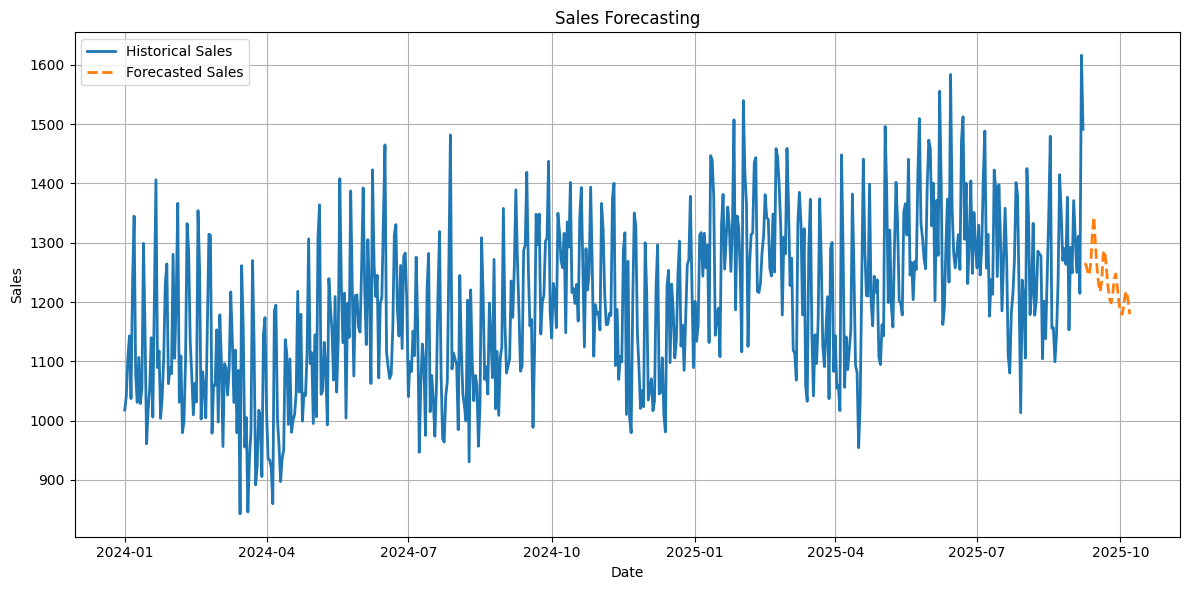

In [52]:

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['sales'], label='Historical Sales', linewidth=2)
plt.plot(future_dates, forecast, label='Forecasted Sales', linestyle='--', linewidth=2)
plt.title('Sales Forecasting')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

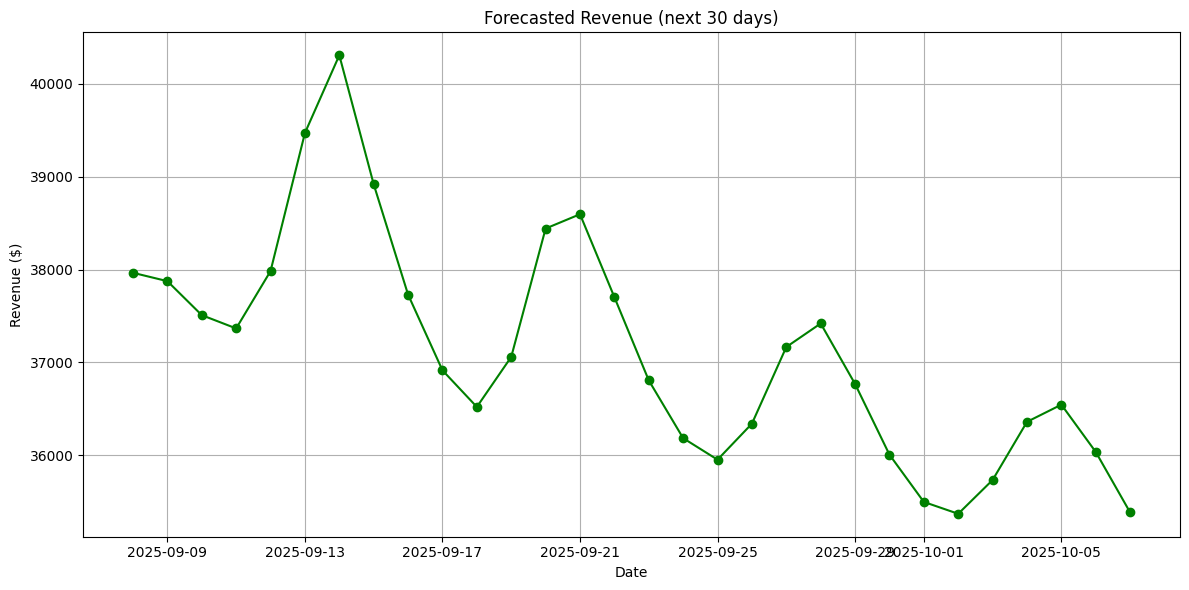

In [53]:
plt.figure(figsize =(12,6))
plt.plot(future_dates, forecast_revenue, marker='o', color='green')
plt.title('Forecasted Revenue (next 30 days)')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.tight_layout()
plt.show()